## Training an Autoencoder on MNIST dataset, and using it for image regeneration

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

We will flatten 28x28 images into 784-dim vectors and normalize them to [0,1]

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.49MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


The below is fully connected Autoencoder:
- Encoder: 784 -> 128 -> 32
- Decoder: 32 -> 128 -> 784

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # output in [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, _ in train_loader:
        # Flatten images
        images = images.view(images.size(0), -1).to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, images)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.0503
Epoch [2/10], Loss: 0.0238
Epoch [3/10], Loss: 0.0175
Epoch [4/10], Loss: 0.0152
Epoch [5/10], Loss: 0.0137
Epoch [6/10], Loss: 0.0126
Epoch [7/10], Loss: 0.0119
Epoch [8/10], Loss: 0.0114
Epoch [9/10], Loss: 0.0109
Epoch [10/10], Loss: 0.0106


In [ ]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.view(images.size(0), -1).to(device)
    reconstructed = model(images)

In [ ]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)

    # Flatten for the autoencoder
    images_flat = images.view(images.size(0), -1)
    reconstructed = model(images_flat)

    # Reshape back to image format
    reconstructed = reconstructed.view(-1, 1, 28, 28)

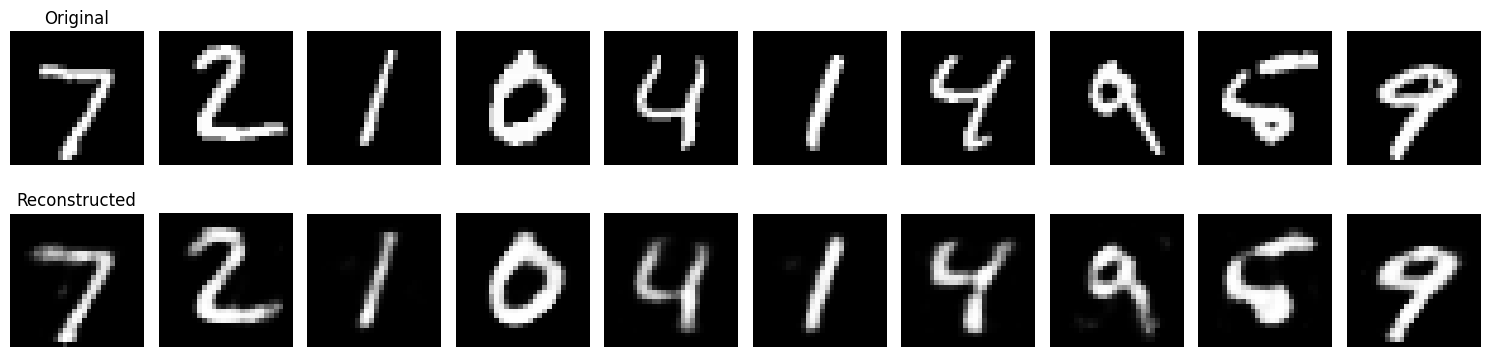

In [ ]:
n = 10  # number of images to display

plt.figure(figsize=(15, 4))

for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstructed")

plt.tight_layout()
plt.show()

### Latent space visualisation is not needed for exam bhayya

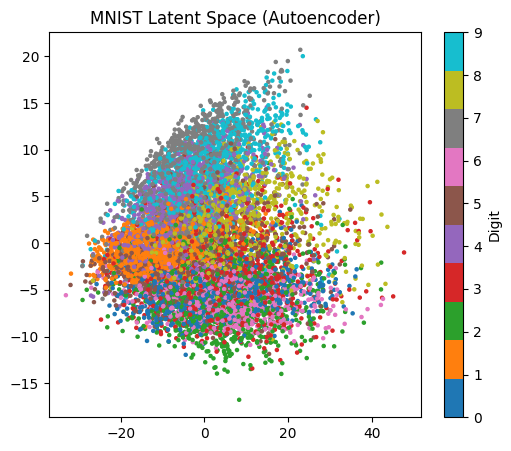

In [ ]:
# Latent space visualization

import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()
latents, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        z = model.encoder(x.view(x.size(0), -1))
        latents.append(z.cpu())
        labels.append(y)

latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()

latents_2d = PCA(n_components=2).fit_transform(latents)

plt.figure(figsize=(6,5))
plt.scatter(latents_2d[:,0], latents_2d[:,1], c=labels, s=5, cmap="tab10")
plt.colorbar(label="Digit")
plt.title("MNIST Latent Space (Autoencoder)")
plt.show()


## Doing using

## CNN Autoencoder

In [ ]:
class CNNAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # (16, 14, 14)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # (32, 7, 7)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7)  # (64, 1, 1)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=7), # (32, 7, 7)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # (16, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # (1, 28, 28)
            nn.Sigmoid() # Output in [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

The above is a Convolutional Autoencoder:
- Encoder: `(1, 28, 28)` -> `(16, 14, 14)` -> `(32, 7, 7)` -> `(64, 1, 1)`
- Decoder: `(64, 1, 1)` -> `(32, 7, 7)` -> `(16, 14, 14)` -> `(1, 28, 28)`

The input image is `1` channel (grayscale) and `28x28` pixels.


In [ ]:
cnn_model = CNNAutoencoder().to(device)
criterion_cnn = nn.MSELoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    cnn_model.train()
    total_loss = 0.0

    for images, _ in train_loader:
        # Images are already in (batch_size, 1, 28, 28) format from ToTensor()
        images = images.to(device)

        # Forward pass
        outputs = cnn_model(images)
        loss = criterion_cnn(outputs, images)

        # Backprop
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.0525
Epoch [2/10], Loss: 0.0113
Epoch [3/10], Loss: 0.0065
Epoch [4/10], Loss: 0.0049
Epoch [5/10], Loss: 0.0041
Epoch [6/10], Loss: 0.0037
Epoch [7/10], Loss: 0.0033
Epoch [8/10], Loss: 0.0031
Epoch [9/10], Loss: 0.0029
Epoch [10/10], Loss: 0.0028


Now let's visualize the reconstructed images using the CNN Autoencoder.

In [ ]:
cnn_model.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)

    reconstructed_cnn = cnn_model(images)

    # No flattening needed for CNN, output is already (batch_size, 1, 28, 28)
    # reconstructed_cnn = reconstructed_cnn.view(-1, 1, 28, 28) # Not needed as output is already correct shape

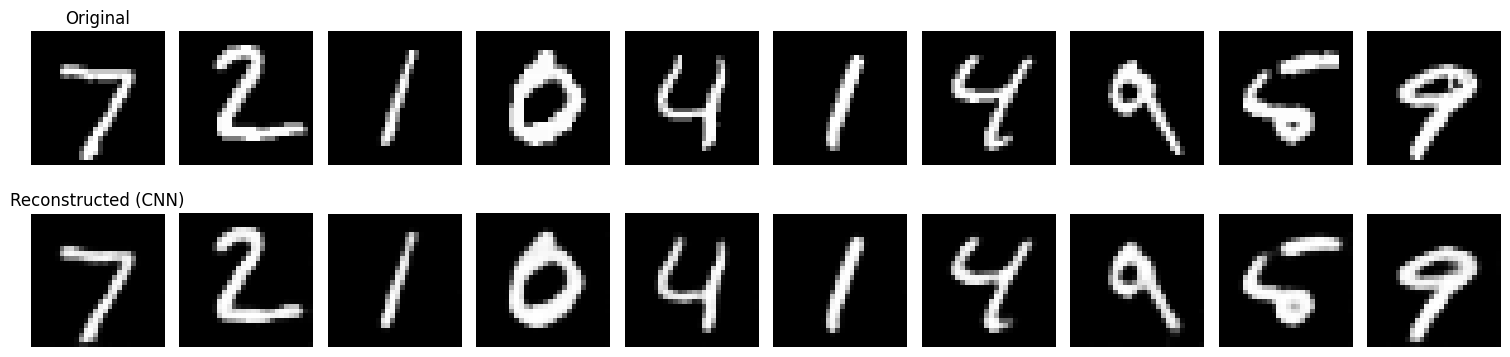

In [ ]:
import matplotlib.pyplot as plt

n = 10  # number of images to display

plt.figure(figsize=(15, 4))

for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_cnn[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstructed (CNN)")

plt.tight_layout()
plt.show()